<a href="https://colab.research.google.com/github/OmarMuhammed77/Diabetes_Risk_Prediction/blob/main/Diabetes_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading and understanding the data**

In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
df=pd.read_csv("/content/diabetes_risk.csv")

In [ ]:
df.shape

(15000, 19)

In [ ]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

In [ ]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,patient_id,int64,"[15000, 1, 2, 3, 4, 5, 6, 7, 14984, 14983]",15000,0,0.000000,0
1,age,int64,"[47, 46, 48, 45, 44, 50, 43, 49, 42, 52]",58,0,0.000000,0
2,gender,object,"[Male, Female, Other]",3,0,0.000000,0
3,city,object,"[Mumbai, Delhi, Bengaluru, Hyderabad, Ahmedaba...",18,0,0.000000,0
4,bmi,float64,"[21.6, 20.8, 21.3, 22.1, 22.2, 24.0, 22.7, 21....",239,0,0.000000,0
5,family_history_diabetes,object,"[No, Yes]",2,0,0.000000,0
6,physical_activity_level,object,"[Active, Sedentary, Moderate]",3,0,0.000000,0
7,diet_type,object,"[Non-Vegetarian, Vegetarian, Pescatarian, Vegan]",4,0,0.000000,0
8,smoking_status,object,"[Never, Current, Former]",3,472,3.146667,0
9,alcohol_consumption,object,"[Never, Occasional, Regular]",3,3788,25.253333,0


In [ ]:
df.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
patient_id,15000.000000,7500.500000,4330.271354,1.000000,3750.750000,7500.500000,11250.250000,15000.000000
age,15000.000000,44.333667,10.383753,18.000000,38.000000,45.000000,52.000000,80.000000
bmi,15000.000000,23.062260,4.046391,15.000000,20.100000,22.700000,25.600000,40.800000
hours_sleep_per_night,15000.000000,7.309860,1.109372,3.000000,6.700000,7.000000,8.000000,12.000000
stress_level,15000.000000,5.941200,2.148406,1.000000,4.000000,6.000000,7.000000,10.000000
fasting_blood_sugar,15000.000000,168.789933,38.365822,72.000000,145.000000,165.000000,189.000000,400.000000
hba1c_level,15000.000000,6.878387,0.843276,4.800000,6.300000,6.800000,7.300000,13.400000
blood_pressure_systolic,15000.000000,139.496200,12.660785,80.000000,130.000000,140.000000,150.000000,200.000000
blood_pressure_diastolic,15000.000000,86.256933,8.386529,50.000000,80.000000,88.000000,90.000000,120.000000
waist_circumference_cm,15000.000000,100.207933,10.760331,73.200000,92.500000,99.300000,106.900000,148.200000


# **EDA**

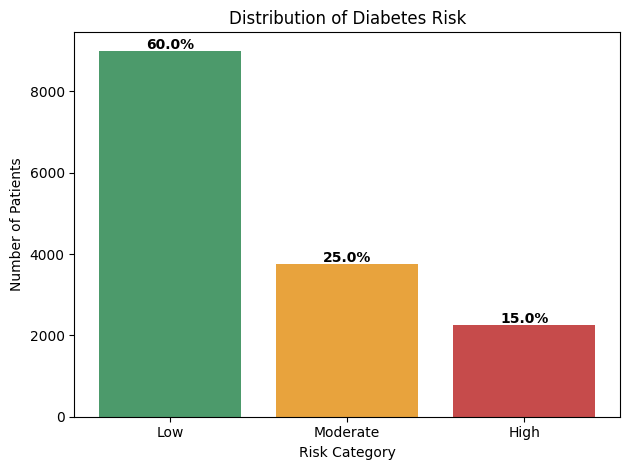

,count
diabetes_risk,
Low,9000
Moderate,3750
High,2250


In [ ]:
RISK_ORDER = ["Low", "Moderate", "High"]
RISK_COLORS = {"Low": "#4C9A6B", "Moderate": "#E8A33D", "High": "#C64B4B"}

risk_counts = df["diabetes_risk"].value_counts().reindex(RISK_ORDER)
risk_pct = (risk_counts / len(df) * 100).round(1)

fig, ax = plt.subplots()
bars = ax.bar(risk_counts.index, risk_counts.values,
              color=[RISK_COLORS[r] for r in RISK_ORDER])
for bar, pct in zip(bars, risk_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{pct}%", ha="center", fontweight="bold")
ax.set_title("Distribution of Diabetes Risk")
ax.set_ylabel("Number of Patients")
ax.set_xlabel("Risk Category")
plt.tight_layout()
plt.show()

risk_counts

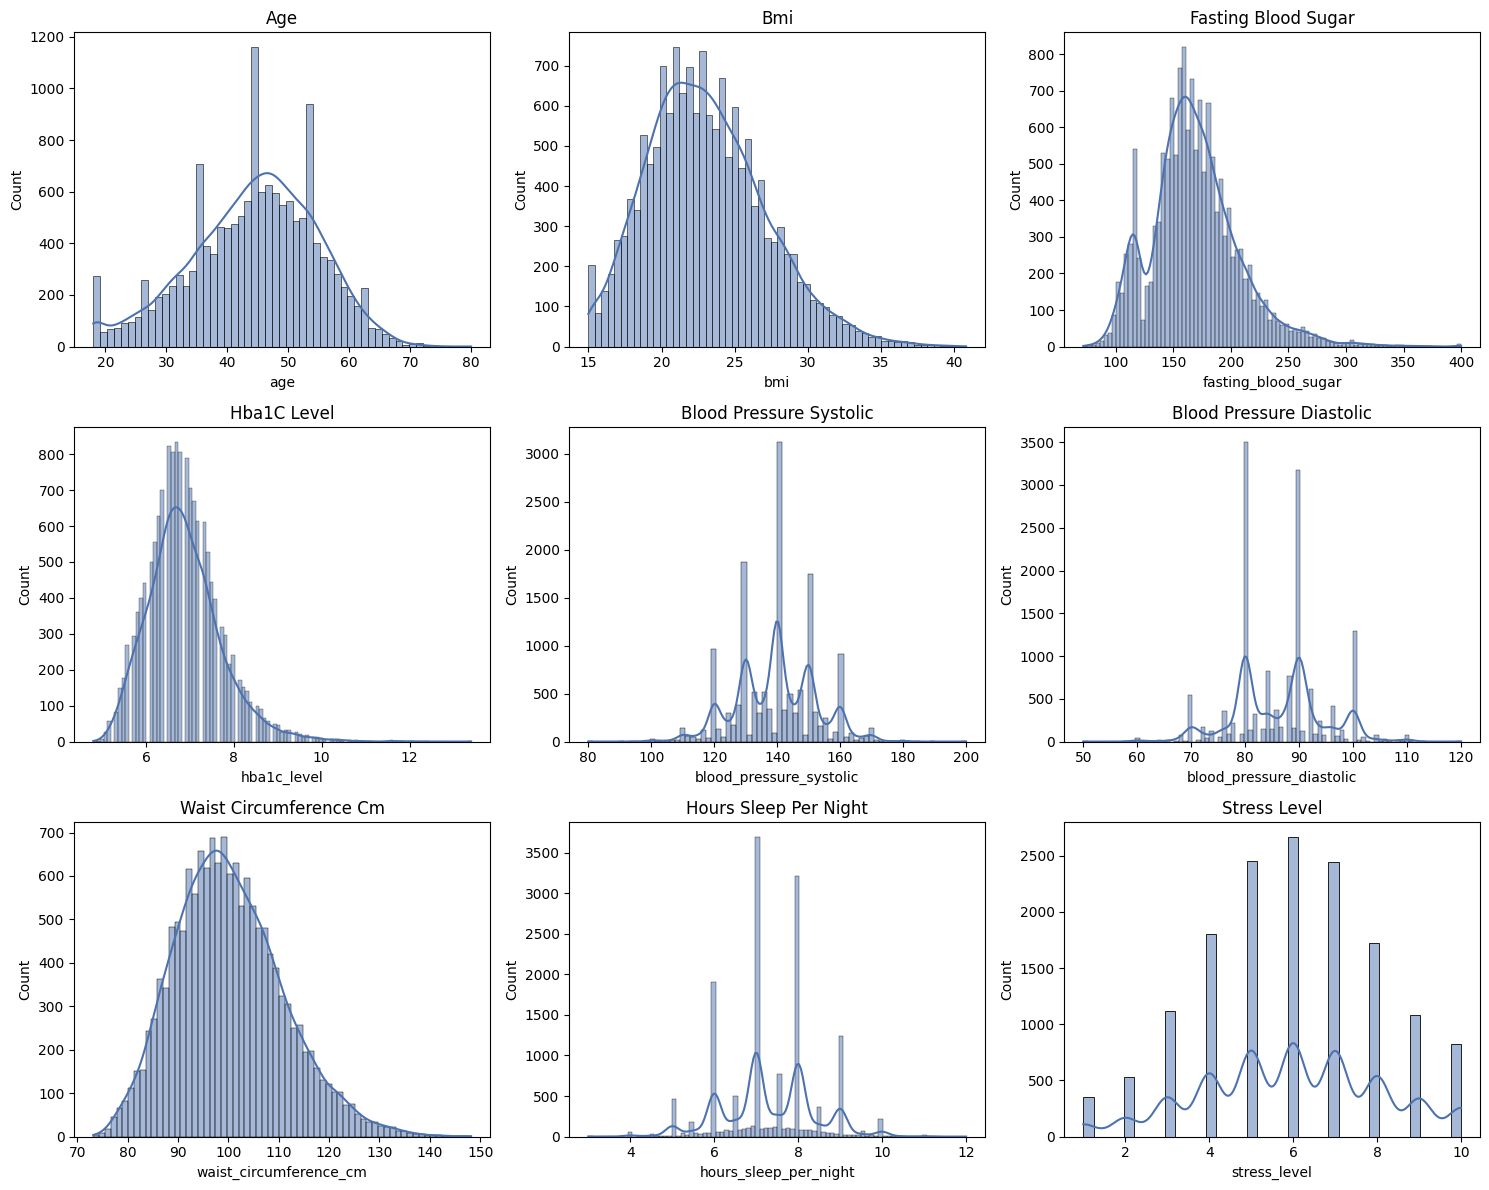

In [ ]:
numeric_cols = ["age", "bmi", "fasting_blood_sugar", "hba1c_level",
                "blood_pressure_systolic", "blood_pressure_diastolic",
                "waist_circumference_cm", "hours_sleep_per_night", "stress_level"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col.replace("_", " ").title())
plt.tight_layout()
plt.show()

### **Checking Outliers**

In [ ]:
checkOutliers=list(df.select_dtypes(include='number'))
checkOutliers.pop(0)
print(checkOutliers)


['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']


/tmp/ipykernel_427/2403418845.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axes[i], palette='magma',whis=1.5)
/tmp/ipykernel_427/2403418845.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axes[i], palette='magma',whis=1.5)
/tmp/ipykernel_427/2403418845.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axes[i], palette='magma',whis=1.5)
/tmp/ipykernel_427/2403418845.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

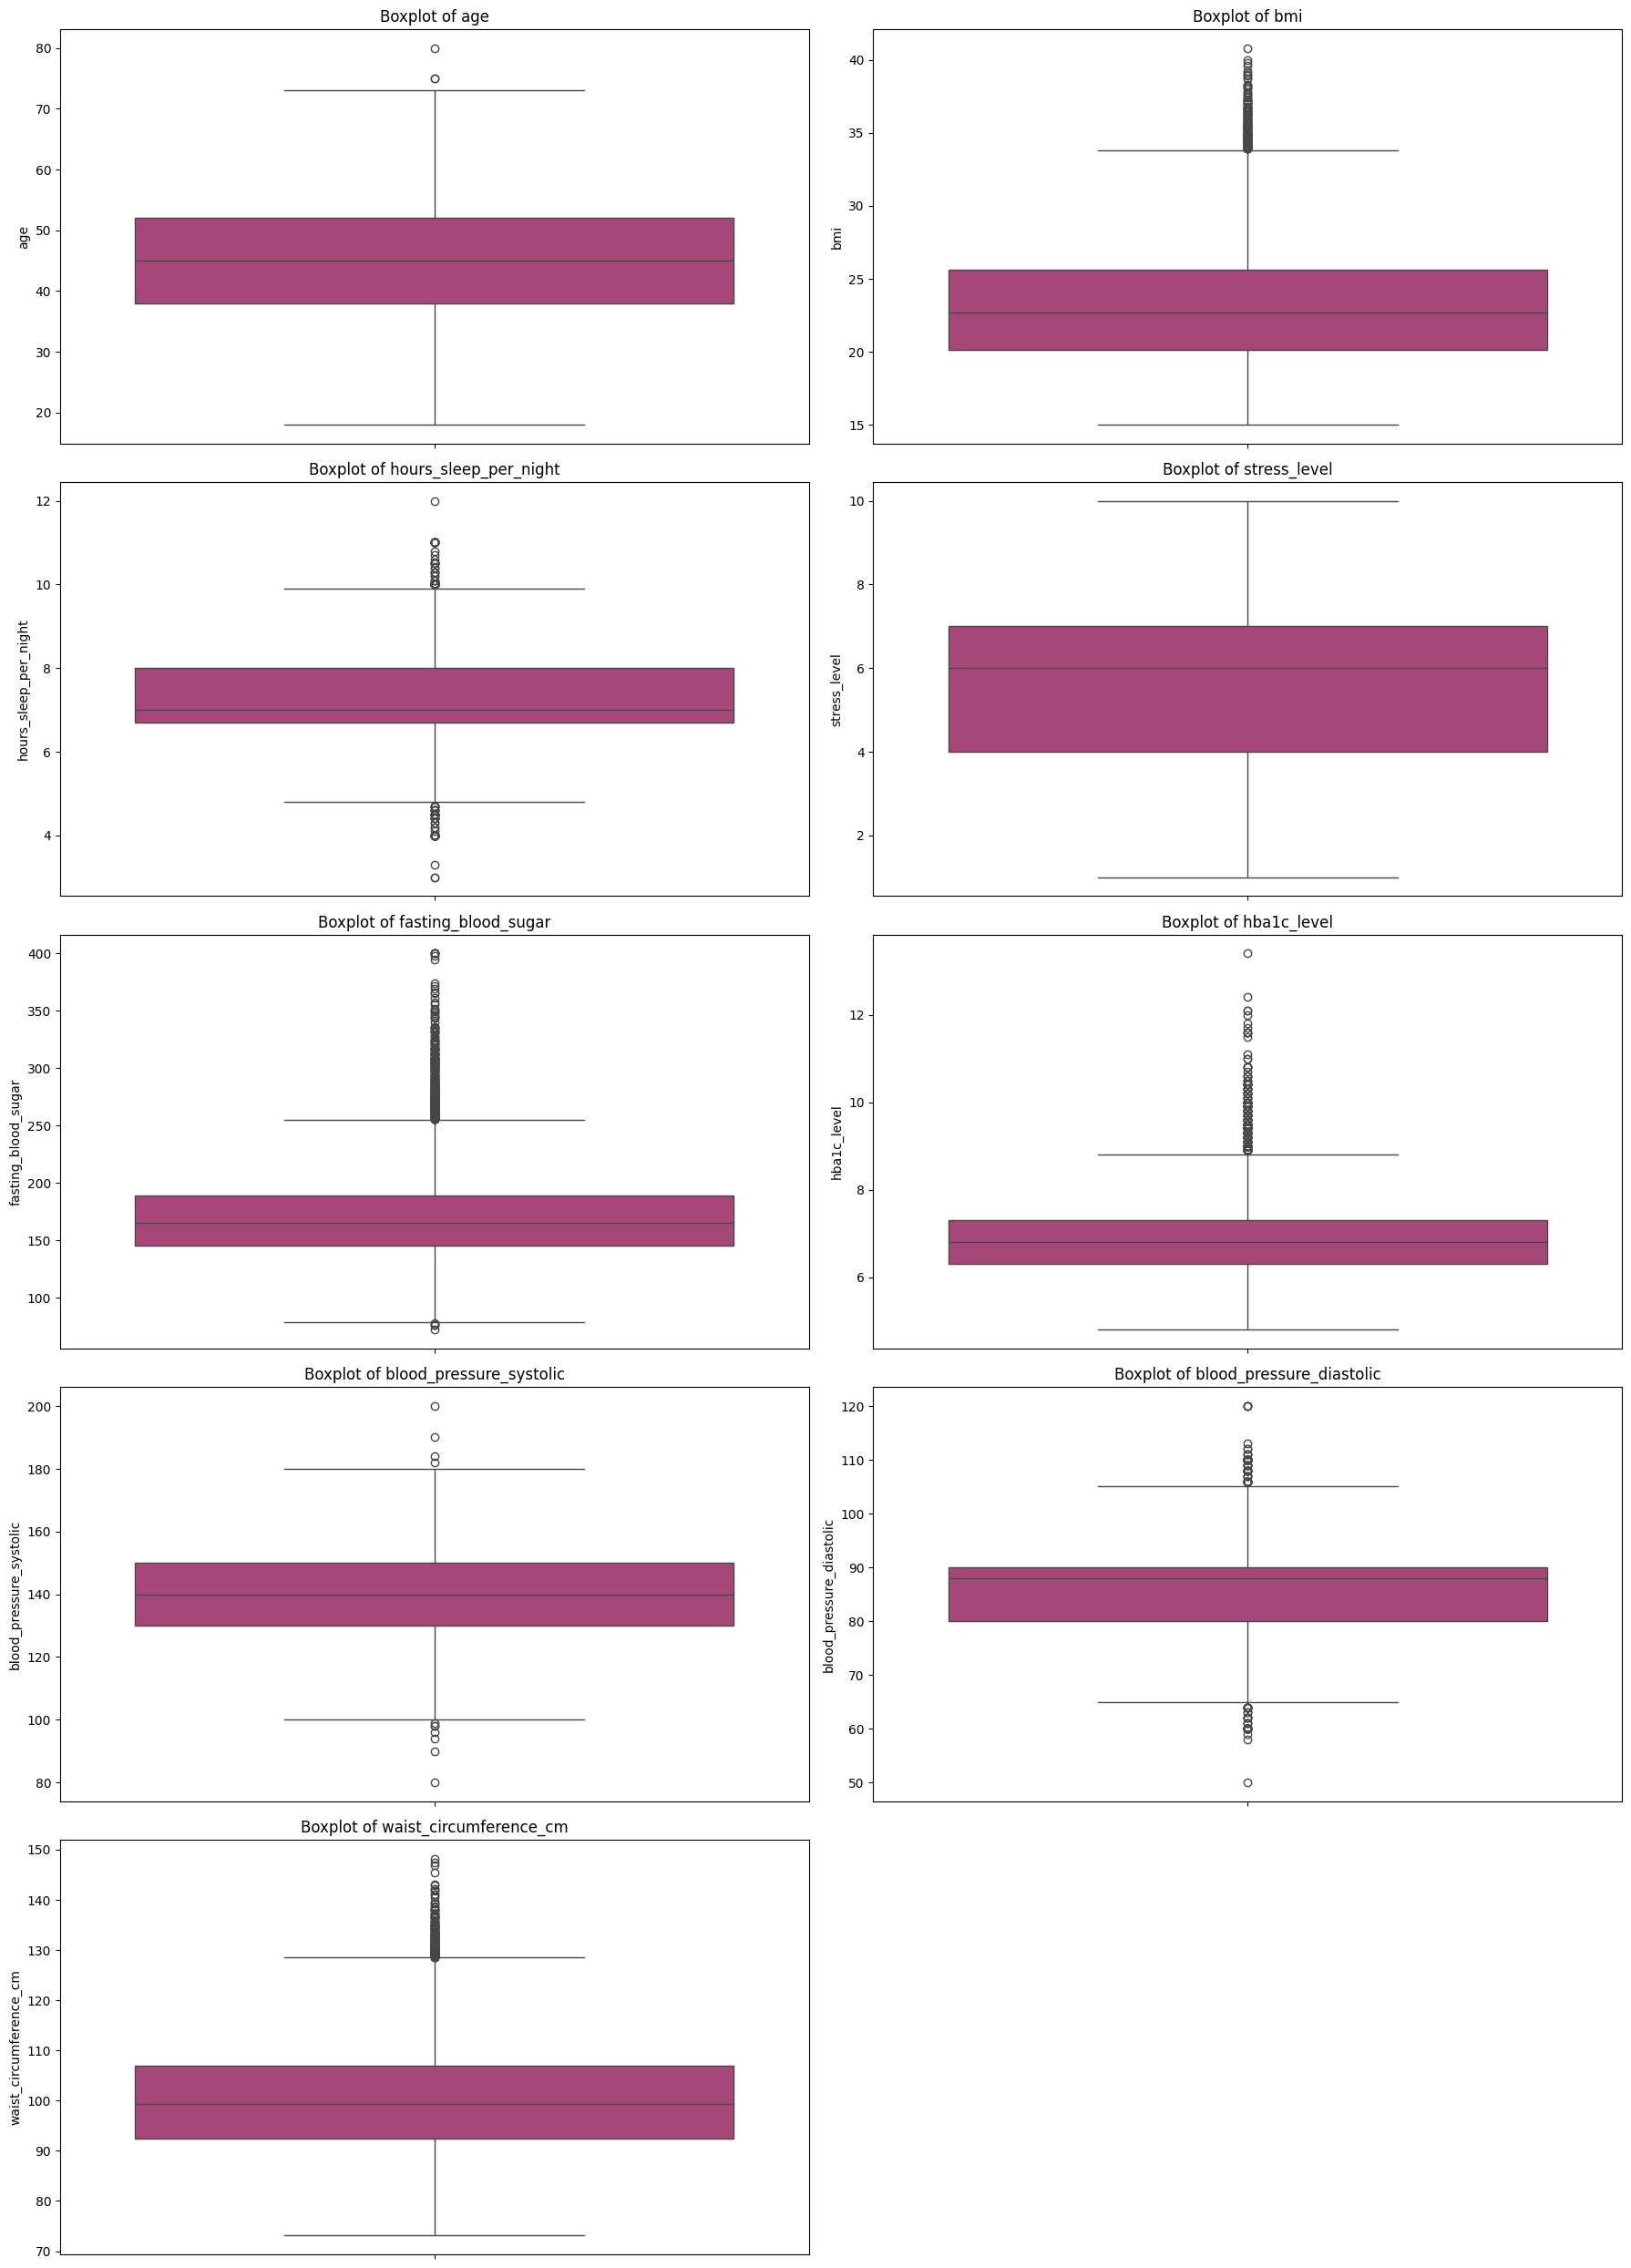

In [ ]:
n_cols = 2
n_rows = int(np.ceil(len(checkOutliers) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(checkOutliers):
    sns.boxplot(data=df, y=col, ax=axes[i], palette='magma',whis=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# **Spliting train/test**





In [ ]:
x=df.drop(['patient_id','diabetes_risk'],axis=1)
y=df['diabetes_risk']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# **Handling Nulls**

In [ ]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
city,0
bmi,0
family_history_diabetes,0
physical_activity_level,0
diet_type,0
smoking_status,472
alcohol_consumption,3788


In [ ]:
numeric_features = x_train.select_dtypes(include=np.number).columns
categorical_features = x_train.select_dtypes(include='object').columns

print("Numerical:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numerical: ['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']
Categorical: ['gender', 'city', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']


In [ ]:
#Handling NULLS on numeric columns

num_imputer = SimpleImputer(strategy='median')

x_train[numeric_features] = num_imputer.fit_transform(x_train[numeric_features])
x_test[numeric_features] = num_imputer.transform(x_test[numeric_features])

In [ ]:
#Handling NULLS categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')

x_train[categorical_features] = cat_imputer.fit_transform(x_train[categorical_features])
x_test[categorical_features] = cat_imputer.transform(x_test[categorical_features])

# **Encoding**

In [ ]:
data_info(x_train.select_dtypes(include='object'))

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,gender,object,"[Male, Female, Other]",3,0,0.0,6841
1,city,object,"[Mumbai, Delhi, Bengaluru, Hyderabad, Ahmedaba...",18,0,0.0,6841
2,family_history_diabetes,object,"[No, Yes]",2,0,0.0,6841
3,physical_activity_level,object,"[Active, Sedentary, Moderate]",3,0,0.0,6841
4,diet_type,object,"[Non-Vegetarian, Vegetarian, Pescatarian, Vegan]",4,0,0.0,6841
5,smoking_status,object,"[Never, Current, Former]",3,0,0.0,6841
6,alcohol_consumption,object,"[Never, Occasional, Regular]",3,0,0.0,6841
7,income_bracket,object,"[Middle, High, Low]",3,0,0.0,6841


In [ ]:
# converting ordinal categories into numerical
# [alcohol_consumption, income_bracket ,physical_activity_level]

activity_mapping = {
    'Sedentary': 0,
    'Moderate': 1,
    'Active': 2
}

alcohol_mapping = {
    'Never': 0,
    'Occasional': 1,
    'Regular': 2
}

income_mapping = {
    'Low': 0,
    'Middle': 1,
    'High': 2
}

x_train['physical_activity_level'] = x_train['physical_activity_level'].map(activity_mapping)
x_test['physical_activity_level'] = x_test['physical_activity_level'].map(activity_mapping)

x_train['alcohol_consumption'] = x_train['alcohol_consumption'].map(alcohol_mapping)
x_test['alcohol_consumption'] = x_test['alcohol_consumption'].map(alcohol_mapping)

x_train['income_bracket'] = x_train['income_bracket'].map(income_mapping)
x_test['income_bracket'] = x_test['income_bracket'].map(income_mapping)

In [ ]:
#binary maping for [family_history_diabetes]

binary_mapping = {
    'No': 0,
    'Yes': 1
}

x_train['family_history_diabetes'] = x_train['family_history_diabetes'].map(binary_mapping)
x_test['family_history_diabetes'] = x_test['family_history_diabetes'].map(binary_mapping)

In [ ]:
#one hot encoder for nominal features
# ['gender', 'city', 'diet_type', 'smoking_status']

nominal_cols= list(x_train.select_dtypes(include='object'))

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

x_train_encoded = encoder.fit_transform(x_train[nominal_cols])
x_test_encoded = encoder.transform(x_test[nominal_cols])

In [ ]:
x_train_encoded = pd.DataFrame(
    x_train_encoded,
    columns=encoder.get_feature_names_out(nominal_cols),
    index=x_train.index
)

x_test_encoded = pd.DataFrame(
    x_test_encoded,
    columns=encoder.get_feature_names_out(nominal_cols),
    index=x_test.index
)

In [ ]:
# data_info(x_train_encoded)

In [ ]:
x_train = x_train.drop(columns=nominal_cols,axis=1)
x_test = x_test.drop(columns=nominal_cols,axis=1)

x_train = pd.concat([x_train, x_train_encoded], axis=1)
x_test = pd.concat([x_test, x_test_encoded], axis=1)


# **Scaling**

In [ ]:
numeric_features

Index(['age', 'bmi', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm'],
      dtype='object')

In [ ]:
# Scaling

scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[numeric_features] = scaler.fit_transform(
    x_train[numeric_features]
)

x_test_scaled[numeric_features] = scaler.transform(
    x_test[numeric_features]
)

# **Feature selection**

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    x_train,
    y_train,
    random_state=32
)

mi_df = pd.DataFrame({
    'Feature': x_train.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

mi_df

,Feature,MI_Score
7,fasting_blood_sugar,0.404571
8,hba1c_level,0.385118
0,age,0.051207
1,bmi,0.044006
11,waist_circumference_cm,0.037258
9,blood_pressure_systolic,0.022365
3,physical_activity_level,0.017979
2,family_history_diabetes,0.016105
10,blood_pressure_diastolic,0.010390
14,gender_Male,0.009314


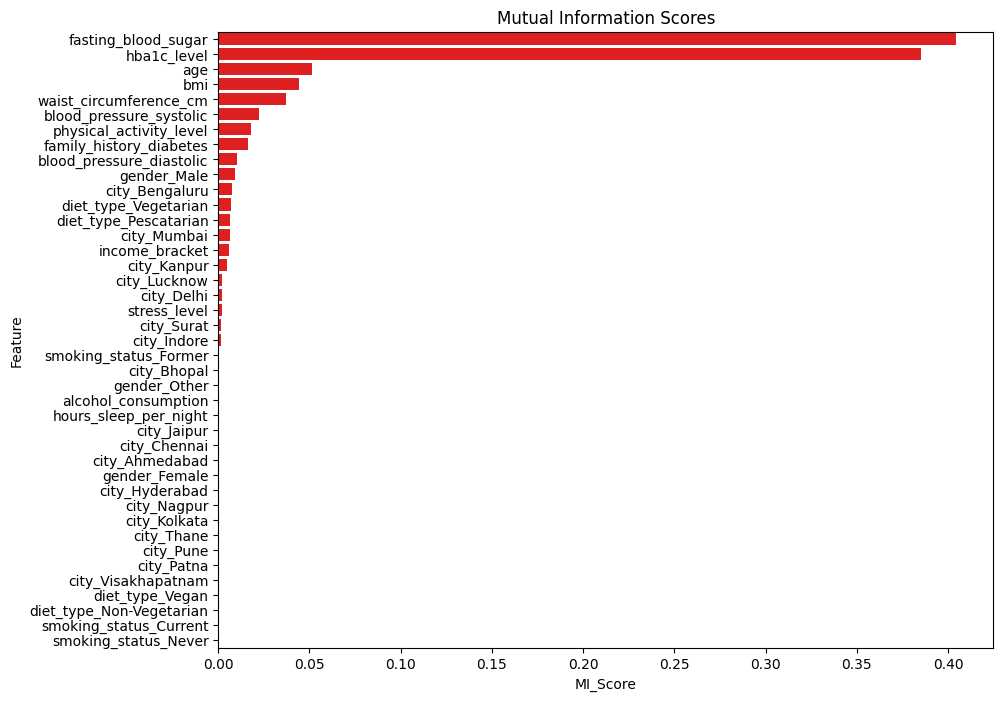

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=mi_df,
    x='MI_Score',
    y='Feature',
    color='r'
)

plt.title('Mutual Information Scores')
plt.show()

# **Logistic Regression**

In [ ]:
# Create model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
# Training
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Prediction
y_pred = model.predict(x_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("---"*20)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7966666666666666
------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

        High       0.81      0.73      0.77       450
         Low       0.86      0.91      0.89      1800
    Moderate       0.61      0.56      0.58       750

    accuracy                           0.80      3000
   macro avg       0.76      0.73      0.75      3000
weighted avg       0.79      0.80      0.79      3000



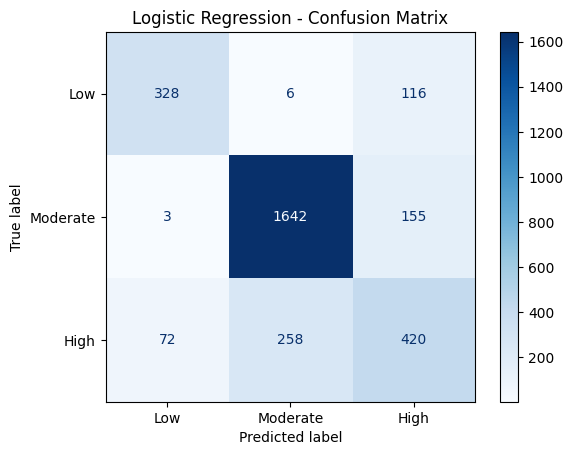

In [262]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Moderate', 'High']
)

disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

# **Logistic Regression** -> (lasso)

In [ ]:
model_lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    C= 0.1,
    random_state=42
)

In [ ]:
model_lasso.fit(x_train_scaled, y_train)

LogisticRegression(C=0.1, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

In [ ]:
y_pred_lasso = model_lasso.predict(x_test_scaled)

In [ ]:
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)

print("Accuracy:", accuracy_lasso)

print("---"*20)
print("Classification Report:")
print(classification_report(y_test, y_pred_lasso))

Accuracy: 0.7723333333333333
------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.78      0.77       450
         Low       0.80      0.95      0.87      1800
    Moderate       0.63      0.34      0.44       750

    accuracy                           0.77      3000
   macro avg       0.73      0.69      0.69      3000
weighted avg       0.75      0.77      0.75      3000



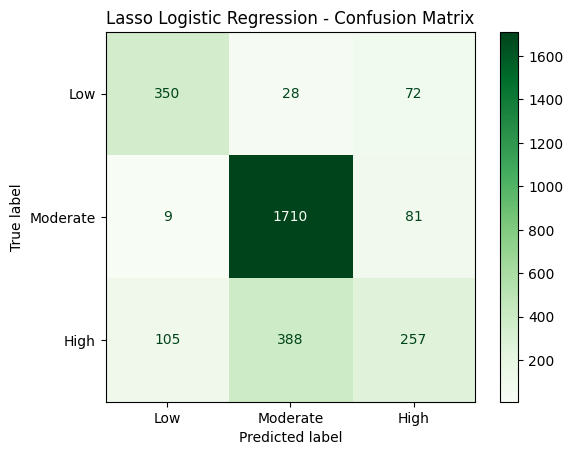

In [255]:

cm = confusion_matrix(y_test, y_pred_lasso)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Moderate', 'High']
)

disp.plot(cmap='Greens')
plt.title('Lasso Logistic Regression - Confusion Matrix')
plt.show()

# **Logistic Regression** -> (ridge)

In [ ]:
model_ridge = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    C= 0.1,
    random_state=42
)


In [ ]:
model_ridge.fit(x_train_scaled, y_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=42)

In [ ]:
y_pred_ridge = model_ridge.predict(x_test_scaled)

In [ ]:
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)

print("Accuracy:", accuracy_ridge)

print("---"*20)
print("Classification Report:")
print(classification_report(y_test, y_pred_ridge))

Accuracy: 0.7953333333333333
------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.72      0.77       450
         Low       0.86      0.91      0.89      1800
    Moderate       0.60      0.56      0.58       750

    accuracy                           0.80      3000
   macro avg       0.76      0.73      0.74      3000
weighted avg       0.79      0.80      0.79      3000



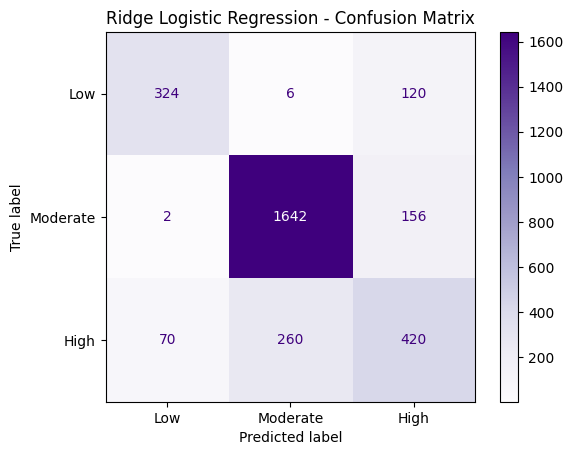

In [256]:
cm = confusion_matrix(y_test, y_pred_ridge)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Moderate', 'High']
)

disp.plot(cmap='Purples')
plt.title('Ridge Logistic Regression - Confusion Matrix')
plt.show()

# **DecisionTreeClassifier**

In [ ]:
# Create model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [ ]:
# Training
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [ ]:
# Prediction
y_pred_dt = dt_model.predict(x_test)

In [ ]:
# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

print("---"*20)

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.765
------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.62      0.70       450
         Low       0.85      0.89      0.87      1800
    Moderate       0.54      0.55      0.55       750

    accuracy                           0.77      3000
   macro avg       0.73      0.69      0.71      3000
weighted avg       0.76      0.77      0.76      3000



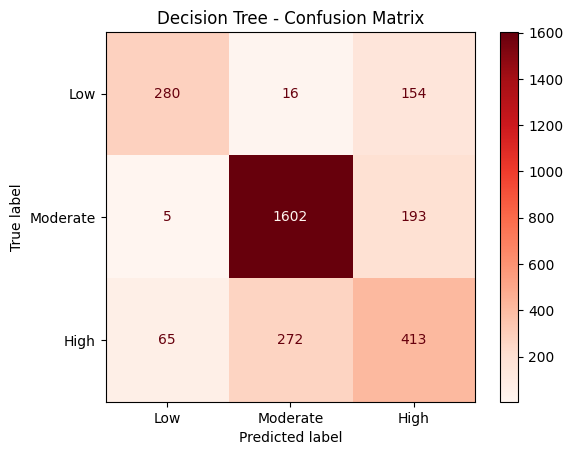

In [261]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Moderate', 'High']
)

disp.plot(cmap='Reds')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

# **RandomForestClassifier**

In [ ]:
# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
# Training
rf_model.fit(x_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(x_test)

In [ ]:
# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("---"*20)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7786666666666666
------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.69      0.74       450
         Low       0.85      0.90      0.88      1800
    Moderate       0.57      0.53      0.55       750

    accuracy                           0.78      3000
   macro avg       0.74      0.71      0.72      3000
weighted avg       0.77      0.78      0.77      3000



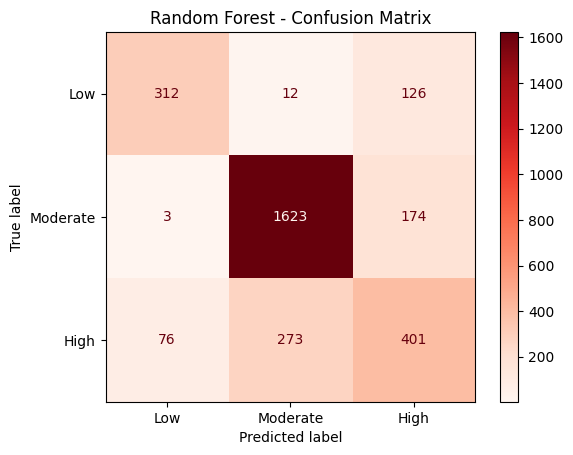

In [259]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Moderate', 'High']
)

disp.plot(cmap='Reds')
plt.title('Random Forest - Confusion Matrix')
plt.show()

# **Comparison of accuracy**

In [ ]:
print("Logistic RegressionAccuracy:", accuracy)
print("--"*30)
print("Logistic Regression(lasso) Accuracy::", accuracy_lasso)
print("--"*30)
print("Logistic Regression(ridge) Accuracy:", accuracy_ridge)
print("--"*30)
print("Decision Tree Accuracy:", accuracy_dt)
print("--"*30)
print("Random Forest Accuracy:", accuracy_rf)

Logistic RegressionAccuracy: 0.7966666666666666
------------------------------------------------------------
Logistic Regression(lasso) Accuracy:: 0.7723333333333333
------------------------------------------------------------
Logistic Regression(ridge) Accuracy: 0.7953333333333333
------------------------------------------------------------
Decision Tree Accuracy: 0.765
------------------------------------------------------------
Random Forest Accuracy: 0.7786666666666666


In [ ]:
results = {
    'Logistic': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='macro'),
        recall_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro')
    ],

    'Lasso': [
        accuracy_score(y_test, y_pred_lasso),
        precision_score(y_test, y_pred_lasso, average='macro'),
        recall_score(y_test, y_pred_lasso, average='macro'),
        f1_score(y_test, y_pred_lasso, average='macro')
    ],

    'Ridge': [
        accuracy_score(y_test, y_pred_ridge),
        precision_score(y_test, y_pred_ridge, average='macro'),
        recall_score(y_test, y_pred_ridge, average='macro'),
        f1_score(y_test, y_pred_ridge, average='macro')
    ],

    'Decision Tree': [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt, average='macro'),
        recall_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_dt, average='macro')
    ],

    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, average='macro'),
        recall_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ]
}

results_df = pd.DataFrame(
    results,
    index=['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
).T

results_df

,Accuracy,Macro Precision,Macro Recall,Macro F1
Logistic,0.796667,0.761067,0.733704,0.746037
Lasso,0.772333,0.728489,0.690148,0.693361
Ridge,0.795333,0.760739,0.730741,0.744174
Decision Tree,0.765000,0.730347,0.687630,0.705104
Random Forest,0.778667,0.740208,0.709889,0.723367


In [248]:
results_weighted = {
    'Logistic': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ],

    'Lasso': [
        accuracy_score(y_test, y_pred_lasso),
        precision_score(y_test, y_pred_lasso, average='weighted'),
        recall_score(y_test, y_pred_lasso, average='weighted'),
        f1_score(y_test, y_pred_lasso, average='weighted')
    ],

    'Ridge': [
        accuracy_score(y_test, y_pred_ridge),
        precision_score(y_test, y_pred_ridge, average='weighted'),
        recall_score(y_test, y_pred_ridge, average='weighted'),
        f1_score(y_test, y_pred_ridge, average='weighted')
    ],

    'Decision Tree': [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted')
    ],

    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
}

results_weighted_df = pd.DataFrame(
    results_weighted,
    index=['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1']
).T

results_weighted_df

,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
Logistic,0.796667,0.790932,0.796667,0.792768
Lasso,0.772333,0.752450,0.772333,0.748325
Ridge,0.795333,0.789942,0.795333,0.791513
Decision Tree,0.765000,0.764427,0.765000,0.762731
Random Forest,0.778667,0.773080,0.778667,0.774719
